# 05 — Octree 3D del universo (Stellar Classification SDSS17)

> **Fase complementaria del playbook** — visualización 3D del universo local + k-NN para la pantalla `/universe`.
>
> El espacio 3D usa `(alpha, delta, redshift)`. Dos artefactos:
> - **`octree.json`** — subdivisión del volumen (decorativo, wireframe en Plotly).
> - **`sample_points.json`** — 10K puntos (estratificados por clase) para `Plotly Scatter3d`.
> 
> El k-NN productivo lo provee `scipy.spatial.cKDTree` construido en el backend al startup (no se serializa — toma <1s reconstruirlo desde los parquets).

## Definition of Done (Día 6)
- [ ] Sample estratificado de 10K puntos (preservando proporciones GALAXY/STAR/QSO).
- [ ] Octree construido sobre coordenadas normalizadas [0,1] (cube uniforme para subdivisión).
- [ ] Cada nodo: `id, depth, bounds (normalized + raw), count, class_distribution, dominant_class, children`.
- [ ] Subdivisión recursiva en 8 octantes con `max_depth` y `min_count` configurables.
- [ ] `octree.json` ≤ 2 MB (target del plan).
- [ ] `sample_points.json` con 10K puntos (≤ 2 MB).
- [ ] Invariante: sum(counts de hojas) == 10,000.
- [ ] Preview matplotlib (3 vistas 2D del scatter).

## Imports y carga del dataset limpio

In [1]:
import json
import time
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
DATA_PATH = ROOT / 'backend' / 'data' / 'star_classification.csv'
FRONTEND_DATA = ROOT / 'frontend' / 'public' / 'data'
DOCS_DIR = ROOT / 'docs'
FRONTEND_DATA.mkdir(parents=True, exist_ok=True)

# Parámetros
SAMPLE_SIZE = 10_000
MAX_DEPTH = 5           # 8^5 = 32,768 nodos max — pero la mayoría se podan por min_count
MIN_COUNT = 50
RANDOM_STATE = 42
CLASS_COLORS = {'GALAXY': '#3b82f6', 'STAR': '#fbbf24', 'QSO': '#a855f7'}

# Cargar y limpiar
df = pd.read_csv(DATA_PATH)
mask = (df[['u', 'g', 'r', 'i', 'z']] == -9999).any(axis=1)
df = df[~mask].copy()
print(f'Dataset limpio: {len(df):,} filas')

Dataset limpio: 99,999 filas


## Paso 1 — Sample estratificado de 10K

Para Plotly Scatter3d: 10K puntos balanceados por clase (preserva proporciones del dataset). Más de 10K laggea en navegador promedio.

In [2]:
# Sample estratificado: misma proporción que el dataset
from sklearn.model_selection import train_test_split
_, df_sample = train_test_split(
    df, test_size=SAMPLE_SIZE / len(df),
    stratify=df['class'], random_state=RANDOM_STATE,
)
df_sample = df_sample.reset_index(drop=True)

print(f'Sample: {len(df_sample):,} filas')
print('\nProporciones (sample vs dataset):')
for cls in ['GALAXY', 'STAR', 'QSO']:
    sample_pct = (df_sample['class'] == cls).mean() * 100
    dataset_pct = (df['class'] == cls).mean() * 100
    print(f'  {cls}: sample {sample_pct:.2f}% vs dataset {dataset_pct:.2f}%')

Sample: 10,000 filas

Proporciones (sample vs dataset):
  GALAXY: sample 59.45% vs dataset 59.45%
  STAR: sample 21.59% vs dataset 21.59%
  QSO: sample 18.96% vs dataset 18.96%


## Paso 2 — Definir el Octree (8 octantes por nodo)

Como las 3 features tienen rangos muy distintos (`alpha∈[0,360]`, `delta∈[-19,83]`, `redshift∈[0,7]`), trabajamos en espacio **normalizado [0,1]**. Los bounds en cada nodo guardan tanto la versión normalizada (para subdivisión) como la versión raw (para que el frontend pueda renderizar).

In [3]:
FEATURES_3D = ['alpha', 'delta', 'redshift']

# Calcular ranges raw para denormalizar
raw_min = df_sample[FEATURES_3D].min().to_dict()
raw_max = df_sample[FEATURES_3D].max().to_dict()

def denormalize(norm_value, feature):
    return raw_min[feature] + norm_value * (raw_max[feature] - raw_min[feature])

# Normalizar coordenadas a [0,1]
df_sample_norm = df_sample[FEATURES_3D].copy()
for col in FEATURES_3D:
    span = raw_max[col] - raw_min[col]
    df_sample_norm[col] = (df_sample[col] - raw_min[col]) / span
df_sample_norm['class'] = df_sample['class'].values

print('Ranges raw vs normalized:')
for col in FEATURES_3D:
    print(f'  {col}: raw [{raw_min[col]:.4f}, {raw_max[col]:.4f}] → norm [0, 1]')


def build_octree(df_norm, bounds_norm, depth=0, max_depth=MAX_DEPTH, min_count=MIN_COUNT, node_id='0'):
    """Construye un octree sobre coordenadas normalizadas [0,1].
    
    bounds_norm: dict con x_min/x_max/y_min/y_max/z_min/z_max (donde x=alpha, y=delta, z=redshift).
    Devuelve lista plana de nodos (cada uno incluye raw_bounds para el frontend).
    """
    count = len(df_norm)
    class_dist = df_norm['class'].value_counts().to_dict() if count > 0 else {}
    dominant = max(class_dist, key=class_dist.get) if class_dist else None
    
    # Calcular bounds raw para este nodo (denormalizar)
    raw_bounds = {
        'alpha_min': denormalize(bounds_norm['x_min'], 'alpha'),
        'alpha_max': denormalize(bounds_norm['x_max'], 'alpha'),
        'delta_min': denormalize(bounds_norm['y_min'], 'delta'),
        'delta_max': denormalize(bounds_norm['y_max'], 'delta'),
        'redshift_min': denormalize(bounds_norm['z_min'], 'redshift'),
        'redshift_max': denormalize(bounds_norm['z_max'], 'redshift'),
    }
    
    is_leaf = (depth >= max_depth) or (count <= min_count) or (count == 0)
    
    if is_leaf:
        return [{
            'id': node_id, 'depth': depth,
            'bounds_norm': bounds_norm, 'bounds_raw': raw_bounds,
            'count': int(count),
            'class_distribution': {k: int(v) for k, v in class_dist.items()},
            'dominant_class': dominant,
            'children': [], 'is_leaf': True,
        }]
    
    # Subdividir en 8 octantes
    x_mid = (bounds_norm['x_min'] + bounds_norm['x_max']) / 2
    y_mid = (bounds_norm['y_min'] + bounds_norm['y_max']) / 2
    z_mid = (bounds_norm['z_min'] + bounds_norm['z_max']) / 2
    
    children_ids = [f'{node_id}-{i}' for i in range(8)]
    nodes = [{
        'id': node_id, 'depth': depth,
        'bounds_norm': bounds_norm, 'bounds_raw': raw_bounds,
        'count': int(count),
        'class_distribution': {k: int(v) for k, v in class_dist.items()},
        'dominant_class': dominant,
        'children': children_ids, 'is_leaf': False,
    }]
    
    # Octantes en orden binario: 0=---, 1=+--, 2=-+-, 3=++-, 4=--+, 5=+-+, 6=-++, 7=+++
    # donde primer signo es x (alpha), segundo y (delta), tercero z (redshift)
    octants = []
    for i in range(8):
        x_lo = bounds_norm['x_min'] if (i & 1) == 0 else x_mid
        x_hi = x_mid if (i & 1) == 0 else bounds_norm['x_max']
        y_lo = bounds_norm['y_min'] if (i & 2) == 0 else y_mid
        y_hi = y_mid if (i & 2) == 0 else bounds_norm['y_max']
        z_lo = bounds_norm['z_min'] if (i & 4) == 0 else z_mid
        z_hi = z_mid if (i & 4) == 0 else bounds_norm['z_max']
        octants.append({
            'x_min': x_lo, 'x_max': x_hi,
            'y_min': y_lo, 'y_max': y_hi,
            'z_min': z_lo, 'z_max': z_hi,
        })
    
    for child_id, oct_b in zip(children_ids, octants):
        # Filtrar puntos en este octante (incluyente abajo, excluyente arriba — salvo borde superior)
        def in_range(col, lo, hi, parent_hi):
            if hi < parent_hi:
                return (df_norm[col] >= lo) & (df_norm[col] < hi)
            return (df_norm[col] >= lo) & (df_norm[col] <= hi)
        
        mask = (
            in_range('alpha', oct_b['x_min'], oct_b['x_max'], bounds_norm['x_max']) &
            in_range('delta', oct_b['y_min'], oct_b['y_max'], bounds_norm['y_max']) &
            in_range('redshift', oct_b['z_min'], oct_b['z_max'], bounds_norm['z_max'])
        )
        nodes.extend(build_octree(df_norm[mask], oct_b, depth + 1, max_depth, min_count, child_id))
    
    return nodes

print(f'Octree builder definido. MAX_DEPTH={MAX_DEPTH}, MIN_COUNT={MIN_COUNT}.')

Ranges raw vs normalized:
  alpha: raw [0.0358, 359.8990] → norm [0, 1]
  delta: raw [-17.4339, 82.5675] → norm [0, 1]
  redshift: raw [-0.0038, 7.0083] → norm [0, 1]
Octree builder definido. MAX_DEPTH=5, MIN_COUNT=50.


## Paso 3 — Construir el octree

In [4]:
ROOT_BOUNDS_NORM = {
    'x_min': 0.0, 'x_max': 1.0,
    'y_min': 0.0, 'y_max': 1.0,
    'z_min': 0.0, 'z_max': 1.0,
}

start = time.time()
nodes = build_octree(df_sample_norm, ROOT_BOUNDS_NORM)
elapsed = time.time() - start

leaves = [n for n in nodes if n['is_leaf']]
internals = [n for n in nodes if not n['is_leaf']]
max_depth_real = max(n['depth'] for n in nodes)

print(f'Octree construido en {elapsed:.2f}s')
print(f'  Total nodos: {len(nodes)}')
print(f'  Hojas: {len(leaves)}')
print(f'  Internos: {len(internals)}')
print(f'  Profundidad real: {max_depth_real}')

# Invariante de conservación
leaf_sum = sum(n['count'] for n in leaves)
print(f'\nInvariante: sum hojas = {leaf_sum:,} | sample = {len(df_sample):,}')
assert leaf_sum == len(df_sample), f'Mismatch: hojas={leaf_sum}, sample={len(df_sample)}'
print('✓ Invariante OK')

# Hojas vacías
empty_leaves = sum(1 for n in leaves if n['count'] == 0)
print(f'\nHojas vacías: {empty_leaves}/{len(leaves)} ({empty_leaves/len(leaves)*100:.1f}%)')

Octree construido en 0.32s
  Total nodos: 873
  Hojas: 764
  Internos: 109
  Profundidad real: 5

Invariante: sum hojas = 10,000 | sample = 10,000
✓ Invariante OK

Hojas vacías: 76/764 (9.9%)


## Paso 4 — Estadísticas del octree por profundidad

In [5]:
depth_stats = Counter(n['depth'] for n in nodes)
leaf_stats = Counter(n['depth'] for n in leaves)

print(f'{"Depth":<6} {"Total":<8} {"Hojas":<8} {"Internos":<10}')
for d in sorted(depth_stats.keys()):
    total = depth_stats[d]
    L = leaf_stats.get(d, 0)
    I = total - L
    print(f'  {d:<6} {total:<8} {L:<8} {I:<10}')

leaf_counts = [n['count'] for n in leaves]
non_empty = [c for c in leaf_counts if c > 0]
print(f'\nCounts en hojas no vacías (n={len(non_empty)}):')
print(f'  min={min(non_empty)}, max={max(non_empty)}, median={np.median(non_empty):.1f}, mean={np.mean(non_empty):.1f}')

Depth  Total    Hojas    Internos  
  0      1        0        1         
  1      8        4        4         
  2      32       11       21        
  3      168      131      37        
  4      296      250      46        
  5      368      368      0         

Counts en hojas no vacías (n=688):
  min=1, max=89, median=11.0, mean=14.5


## Paso 5 — Preview matplotlib (3 proyecciones 2D del scatter 3D)

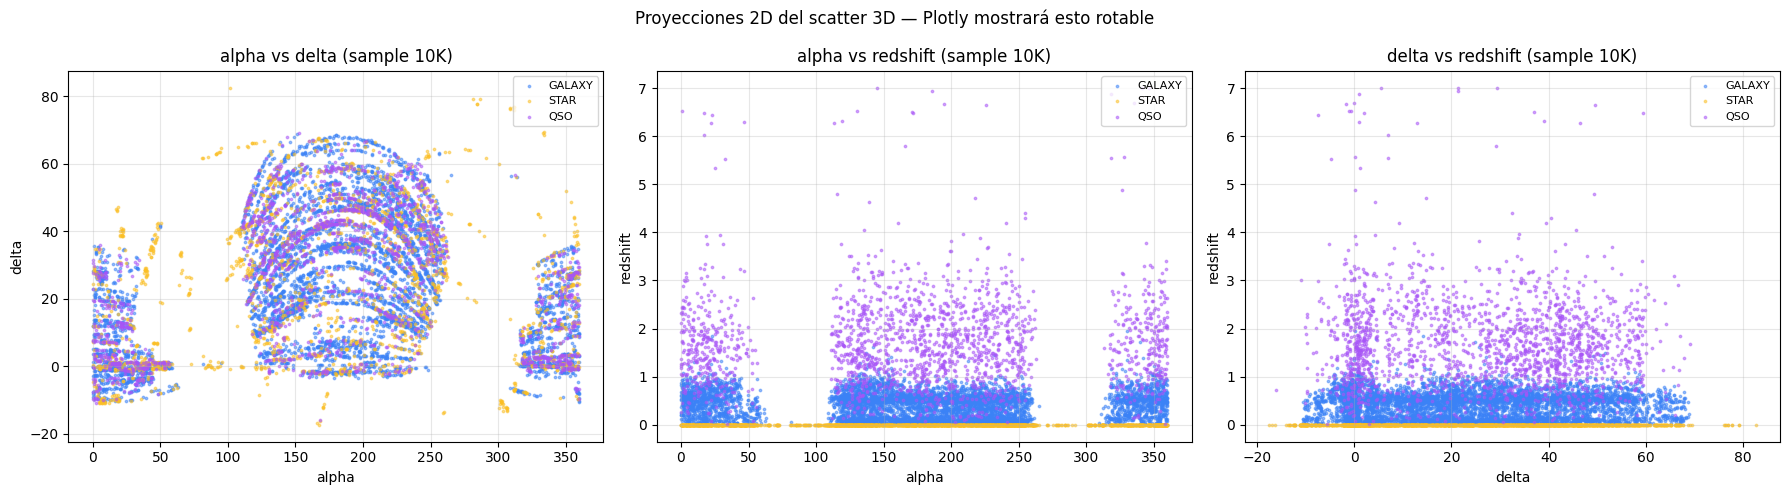

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [('alpha', 'delta'), ('alpha', 'redshift'), ('delta', 'redshift')]
for ax, (xcol, ycol) in zip(axes, pairs):
    for cls, color in CLASS_COLORS.items():
        sub = df_sample[df_sample['class'] == cls]
        ax.scatter(sub[xcol], sub[ycol], s=3, alpha=0.5, c=color, label=cls)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f'{xcol} vs {ycol} (sample 10K)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Proyecciones 2D del scatter 3D — Plotly mostrará esto rotable')
plt.tight_layout()
plt.show()

## Paso 6 — Exportar JSON: octree + sample_points

In [7]:
# Octree
octree_payload = {
    'metadata': {
        'generated_at': datetime.utcnow().isoformat() + 'Z',
        'sample_size': len(df_sample),
        'max_depth': MAX_DEPTH,
        'min_count': MIN_COUNT,
        'features_3d': FEATURES_3D,
        'random_state': RANDOM_STATE,
    },
    'raw_ranges': {col: {'min': raw_min[col], 'max': raw_max[col]} for col in FEATURES_3D},
    'stats': {
        'total_nodes': len(nodes),
        'leaves': len(leaves),
        'internal': len(internals),
        'empty_leaves': int(empty_leaves),
        'max_depth_real': int(max_depth_real),
    },
    'nodes': nodes,
}

OCTREE_OUT = FRONTEND_DATA / 'octree.json'
OCTREE_OUT.write_text(json.dumps(octree_payload))
octree_size_kb = OCTREE_OUT.stat().st_size / 1024
print(f'✓ octree.json: {OCTREE_OUT.name} ({octree_size_kb:.1f} KB)')

# Sample points (los 10K para Plotly Scatter3d)
sample_payload = {
    'metadata': {
        'generated_at': datetime.utcnow().isoformat() + 'Z',
        'count': len(df_sample),
        'stratified_by': 'class',
        'random_state': RANDOM_STATE,
    },
    'features': FEATURES_3D,
    'class_colors': CLASS_COLORS,
    # Compacto: arrays paralelos en vez de objetos (ahorra 60-70% del JSON)
    'alpha': df_sample['alpha'].round(4).tolist(),
    'delta': df_sample['delta'].round(4).tolist(),
    'redshift': df_sample['redshift'].round(6).tolist(),
    'class': df_sample['class'].tolist(),
    'obj_ID': df_sample['obj_ID'].astype(str).tolist(),  # opcional, para tooltip
}

SAMPLE_OUT = FRONTEND_DATA / 'sample_points.json'
SAMPLE_OUT.write_text(json.dumps(sample_payload))
sample_size_kb = SAMPLE_OUT.stat().st_size / 1024
print(f'✓ sample_points.json: {SAMPLE_OUT.name} ({sample_size_kb:.1f} KB)')

if octree_size_kb > 2000:
    print(f'  ⚠ octree.json > 2 MB — reducir MAX_DEPTH si frontend laggea')
if sample_size_kb > 2000:
    print(f'  ⚠ sample_points.json > 2 MB — reducir SAMPLE_SIZE')

✓ octree.json: octree.json (419.7 KB)
✓ sample_points.json: sample_points.json (614.9 KB)


## Paso 7 — Generar octree_summary.json

In [8]:
summary = {
    'timestamp': datetime.utcnow().isoformat() + 'Z',
    'parameters': {
        'sample_size': SAMPLE_SIZE,
        'max_depth': MAX_DEPTH,
        'min_count': MIN_COUNT,
        'random_state': RANDOM_STATE,
    },
    'sample': {
        'rows': len(df_sample),
        'stratified': True,
        'proportions': {cls: float((df_sample['class'] == cls).mean()) for cls in ['GALAXY', 'STAR', 'QSO']},
    },
    'raw_ranges': octree_payload['raw_ranges'],
    'tree': {
        'total_nodes': len(nodes),
        'leaves': len(leaves),
        'internal': len(internals),
        'empty_leaves': int(empty_leaves),
        'max_depth_real': int(max_depth_real),
        'nodes_per_depth': {str(d): depth_stats[d] for d in sorted(depth_stats.keys())},
    },
    'invariant_check': {
        'sum_leaves_eq_sample': leaf_sum == len(df_sample),
        'leaf_sum': leaf_sum,
        'sample_size': len(df_sample),
    },
    'output': {
        'octree_path': str(OCTREE_OUT.relative_to(ROOT)),
        'octree_size_kb': round(octree_size_kb, 2),
        'sample_path': str(SAMPLE_OUT.relative_to(ROOT)),
        'sample_size_kb': round(sample_size_kb, 2),
    },
    'decisions': [
        f'Sample estratificado de {SAMPLE_SIZE:,} puntos (preserva proporciones del dataset).',
        'Octree construido sobre coordenadas NORMALIZADAS [0,1] (cube uniforme).',
        'Cada nodo expone bounds_norm (subdivisión) Y bounds_raw (renderizado frontend).',
        f'MAX_DEPTH={MAX_DEPTH}, MIN_COUNT={MIN_COUNT} → JSON ~{octree_size_kb:.0f}KB (target <2MB).',
        'sample_points.json usa arrays paralelos (compacto, ~60% más chico que objetos JSON).',
        'cKDTree para k-NN productivo NO se serializa — se reconstruye en backend lifespan (<1s).',
    ],
}

SUMMARY_PATH = DOCS_DIR / 'octree_summary.json'
SUMMARY_PATH.write_text(json.dumps(summary, indent=2))
print(f'✓ octree_summary.json escrito')
print(json.dumps(summary, indent=2))

✓ octree_summary.json escrito
{
  "timestamp": "2026-05-27T16:11:21.621551Z",
  "parameters": {
    "sample_size": 10000,
    "max_depth": 5,
    "min_count": 50,
    "random_state": 42
  },
  "sample": {
    "rows": 10000,
    "stratified": true,
    "proportions": {
      "GALAXY": 0.5945,
      "STAR": 0.2159,
      "QSO": 0.1896
    }
  },
  "raw_ranges": {
    "alpha": {
      "min": 0.0357736532100716,
      "max": 359.899045806994
    },
    "delta": {
      "min": -17.4339461952334,
      "max": 82.5675002940135
    },
    "redshift": {
      "min": -0.003844469,
      "max": 7.008322
    }
  },
  "tree": {
    "total_nodes": 873,
    "leaves": 764,
    "internal": 109,
    "empty_leaves": 76,
    "max_depth_real": 5,
    "nodes_per_depth": {
      "0": 1,
      "1": 8,
      "2": 32,
      "3": 168,
      "4": 296,
      "5": 368
    }
  },
  "invariant_check": {
    "sum_leaves_eq_sample": true,
    "leaf_sum": 10000,
    "sample_size": 10000
  },
  "output": {
    "octree_pa

## Resumen

- ✅ Octree custom sobre coordenadas normalizadas [0,1].
- ✅ Sample estratificado de 10K para Plotly Scatter3d.
- ✅ Invariante de conservación validado.
- ✅ JSON exportados a `frontend/public/data/` (octree.json + sample_points.json).

**Siguiente**: backend con `/api/octree`, `/api/neighbors` (cKDTree built at startup), `/api/sample` para el scatter.